# Dubins Path Planning

Aircraft cannot make instantaneous turns — they follow curved trajectories
constrained by their minimum turning radius. A Dubins path is the shortest
path between two oriented waypoints (position + heading) that respects a
minimum turning radius constraint. HyPlan uses Dubins paths to model
realistic aircraft maneuvers between flight lines.

The 3D extension (Vana et al., ICRA 2020) adds altitude and pitch angle
constraints, producing paths that respect both turn radius and climb/descent
limits. The algorithm decomposes the problem into two coupled sub-problems:

- **Horizontal**: Dubins path in (x, y) with heading
- **Vertical**: Dubins path in (arc-length, altitude) with pitch angle

These are linked by a curvature budget:

$$\frac{1}{\rho_{min}^2} = \frac{1}{\rho_h^2} + \frac{1}{\rho_v^2}$$

For level flight, the vertical component vanishes and the path reduces to a
horizontal Dubins path.

`DubinsPath3D` handles both level and altitude-changing paths.

This notebook covers:

1. Creating waypoints with position and heading
2. Computing Dubins paths between waypoint pairs
3. Multi-segment routes
4. Path serialization
5. 3D paths: climbing and descending
6. Effect of pitch limits on path geometry
7. Turning with altitude change
8. Integration with flight lines
9. Effect of speed and bank angle on path geometry
10. Closed-loop routes
11. Pitch limits from aircraft performance
12. Integration with the flight plan pipeline

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

from hyplan.waypoint import Waypoint
from hyplan.dubins3d import DubinsPath3D
from hyplan.flight_line import FlightLine
from hyplan.geometry import wrap_to_360
from hyplan.units import ureg

## 1. Waypoints

A `Waypoint` defines a position (lat/lon), a heading (degrees from north),
and an optional altitude and name. Waypoints are the inputs to the Dubins
path solver.

In [2]:
# Create waypoints with different headings
wp1 = Waypoint(latitude=34.20, longitude=-118.35, heading=90.0, name="WP1 East")
wp2 = Waypoint(latitude=34.10, longitude=-118.15, heading=270.0, name="WP2 West")
wp3 = Waypoint(latitude=34.20, longitude=-117.95, heading=90.0, name="WP3 East")

print(f"Waypoint 1: {wp1.name}")
print(f"  Position: ({wp1.latitude}, {wp1.longitude})")
print(f"  Heading:  {wp1.heading} deg")
print(f"  Geometry: {wp1.geometry}")
print()

# Waypoints can include altitude
wp_alt = Waypoint(latitude=34.15, longitude=-118.25, heading=180.0,
                  altitude_msl=6000 * ureg.meter, name="WP with altitude")
print(f"{wp_alt.name}: altitude = {wp_alt.altitude_msl}")

# Dictionary representation
print(f"\nDictionary: {wp1.to_dict()}")

Waypoint 1: WP1 East
  Position: (34.2, -118.35)
  Heading:  90.0 deg
  Geometry: POINT (-118.35 34.2)

WP with altitude: altitude = 6000 meter

Dictionary: {'latitude': 34.2, 'longitude': -118.35, 'heading': np.float64(90.0), 'altitude_msl': None, 'name': 'WP1 East'}


## 2. Computing a Dubins Path

`DubinsPath3D` connects two waypoints with the shortest feasible path. The turn
radius is determined by the aircraft's speed and bank angle:

$$r = \frac{v^2}{g \cdot \tan(\theta)}$$

where $v$ is speed (m/s), $g$ is gravity (9.8 m/s$^2$), and $\theta$ is bank angle.

Both waypoints must have `altitude_msl` set. For level flight, use the same
altitude for both waypoints.

Turn radius: 2180 m (1.2 nmi)
Path length: 26428.725325243253 meter
Path points: 265


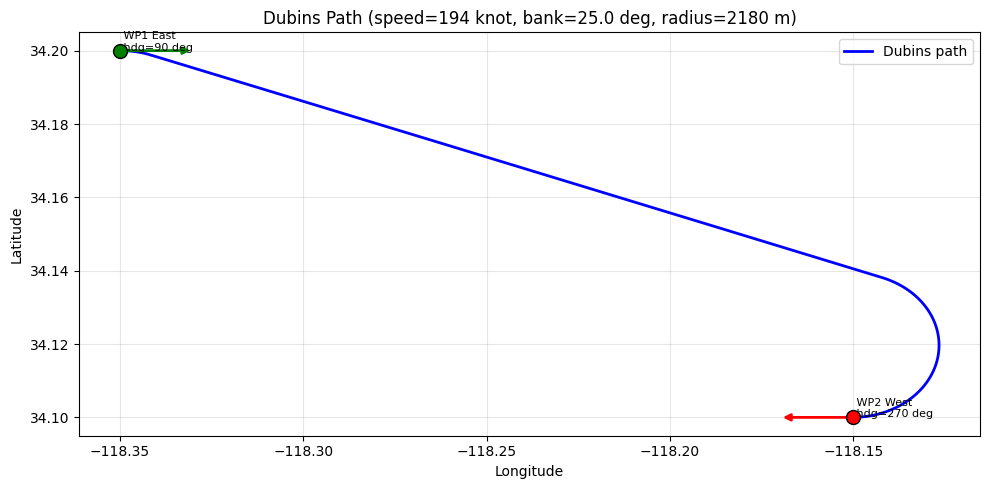

In [3]:
# Compute a Dubins path between two waypoints
speed = ureg.Quantity(194, "knot")  # ~100 m/s, typical for King Air
bank_angle = 25.0   # degrees (standard rate turn)
step_size = 100.0   # meters (sampling resolution)

# Add altitude for DubinsPath3D (level flight)
wp1_alt = Waypoint(wp1.latitude, wp1.longitude, wp1.heading,
                   altitude_msl=ureg.Quantity(20000, "feet"), name=wp1.name)
wp2_alt = Waypoint(wp2.latitude, wp2.longitude, wp2.heading,
                   altitude_msl=ureg.Quantity(20000, "feet"), name=wp2.name)

path = DubinsPath3D(
    start=wp1_alt,
    end=wp2_alt,
    speed=speed,
    bank_angle=bank_angle,
    pitch_min=-10.0, pitch_max=10.0,
    step_size=step_size,
)

# Turn radius
speed_mps = speed.to("m/s").magnitude
turn_radius = speed_mps**2 / (9.8 * np.tan(np.radians(bank_angle)))
print(f"Turn radius: {turn_radius:.0f} m ({turn_radius / 1852:.1f} nmi)")
print(f"Path length: {path.length}")
print(f"Path points: {len(list(path.geometry.coords))}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
lons, lats = zip(*list(path.geometry.coords))
ax.plot(lons, lats, "b-", linewidth=2, label="Dubins path")

# Mark waypoints with heading arrows
for wp, color in [(wp1_alt, "green"), (wp2_alt, "red")]:
    ax.scatter(wp.longitude, wp.latitude, c=color, s=100, zorder=5, edgecolors="black")
    dx = 0.02 * np.sin(np.radians(wp.heading))
    dy = 0.02 * np.cos(np.radians(wp.heading))
    ax.annotate("", xy=(wp.longitude + dx, wp.latitude + dy),
                xytext=(wp.longitude, wp.latitude),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2))
    ax.annotate(f" {wp.name}\n hdg={wp.heading:.0f} deg",
                (wp.longitude, wp.latitude), fontsize=8)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Dubins Path (speed={speed}, bank={bank_angle} deg, radius={turn_radius:.0f} m)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 3. Multi-Segment Routes

Chain multiple Dubins paths together to model a complete route through
a sequence of waypoints — for example, connecting consecutive flight lines.

Route: 5 segments, total distance: 134960 m (72.9 nmi)


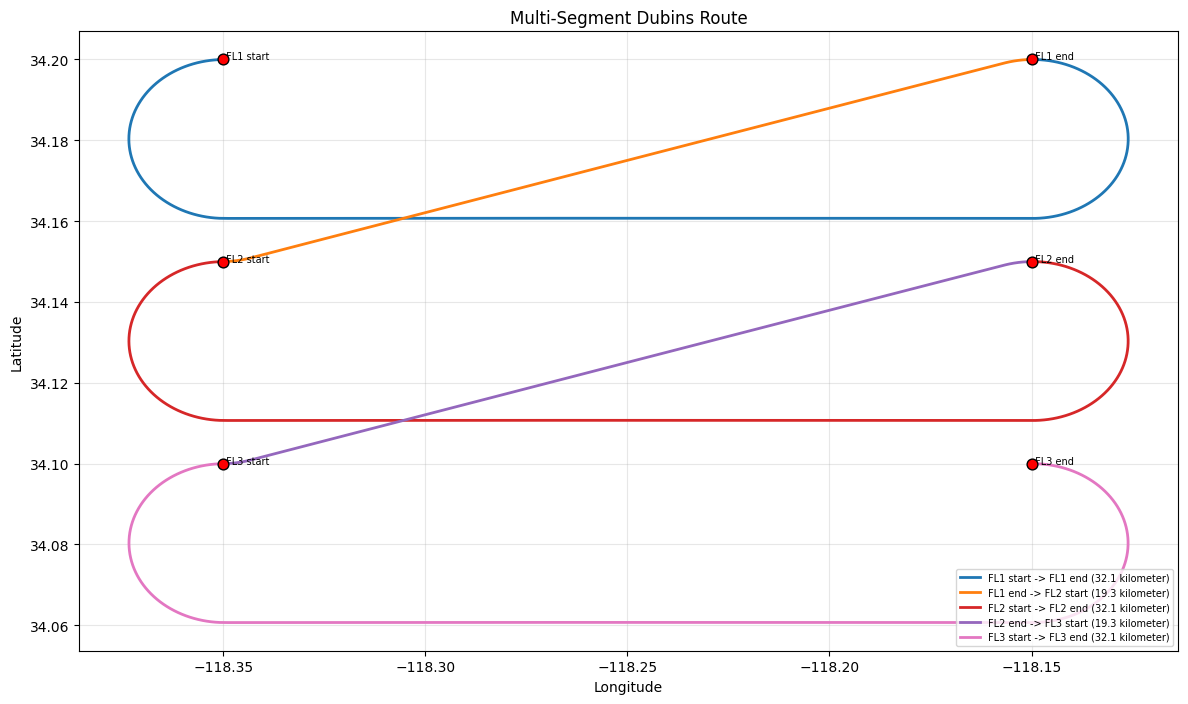

In [4]:
# Define a sequence of waypoints simulating flight line endpoints
ALT = ureg.Quantity(20000, "feet")
waypoints = [
    Waypoint(34.20, -118.35, wrap_to_360(270.0), altitude_msl=ALT, name="FL1 start"),
    Waypoint(34.20, -118.15, wrap_to_360(270.0), altitude_msl=ALT, name="FL1 end"),
    Waypoint(34.15, -118.35, wrap_to_360(270.0), altitude_msl=ALT, name="FL2 start"),
    Waypoint(34.15, -118.15, wrap_to_360(270.0), altitude_msl=ALT, name="FL2 end"),
    Waypoint(34.10, -118.35, wrap_to_360(270.0), altitude_msl=ALT, name="FL3 start"),
    Waypoint(34.10, -118.15, wrap_to_360(270.0), altitude_msl=ALT, name="FL3 end"),
]

# Compute Dubins paths between consecutive waypoints
paths = []
total_distance = 0
for i in range(len(waypoints) - 1):
    dp = DubinsPath3D(waypoints[i], waypoints[i + 1], speed=speed,
                      bank_angle=25.0, pitch_min=-10.0, pitch_max=10.0,
                      step_size=100.0)
    paths.append(dp)
    total_distance += dp.length.to("m").magnitude

print(f"Route: {len(paths)} segments, total distance: {total_distance:.0f} m "
      f"({total_distance / 1852:.1f} nmi)")

# Plot the route
fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.tab10(np.linspace(0, 0.6, len(paths)))

for i, (dp, color) in enumerate(zip(paths, colors)):
    lons, lats = zip(*list(dp.geometry.coords))
    label = f"{waypoints[i].name} -> {waypoints[i+1].name} ({dp.length.to('km'):.1f})"
    ax.plot(lons, lats, color=color, linewidth=2, label=label)

# Plot waypoints
for wp in waypoints:
    ax.scatter(wp.longitude, wp.latitude, c="red", s=60, zorder=5, edgecolors="black")
    ax.annotate(f" {wp.name}", (wp.longitude, wp.latitude), fontsize=7)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Multi-Segment Dubins Route")
ax.legend(fontsize=7, loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 4. Path Serialization

`DubinsPath3D.to_dict()` serializes the path for export, including start/end
coordinates, headings, altitudes, and total distance.

In [5]:
d = path.to_dict()
for key, val in d.items():
    if key != "geometry":
        print(f"  {key}: {val}")
print(f"  geometry: LineString with {len(list(path.geometry.coords))} points")

  geometry_3d: LINESTRING Z (-118.35 34.19999999999999 6095.999999999999, -118.34891376000937 34.19999122776574 6095.999999999999, -118.34782915029608 34.199941026014784 6095.999999999999, -118.34674845895252 34.19984950061395 6095.999999999999, -118.3456739657919 34.199716844605675 6095.999999999999, -118.34460793752879 34.19954333780031 6095.999999999999, -118.34355262298756 34.19932934618494 6095.999999999999, -118.34251024834897 34.199075321150076 6095.999999999999, -118.34148293986775 34.19878196304087 6095.999999999999, -118.34046242039537 34.198472464150115 6095.999999999999, -118.33944190813054 34.1981629565747 6095.999999999999, -118.33842140307345 34.197853440314915 6095.999999999999, -118.33740090522446 34.19754391537106 6095.999999999999, -118.33638041458373 34.19723438174342 6095.999999999999, -118.33535993115159 34.19692483943227 6095.999999999999, -118.33433945492827 34.19661528843791 6095.999999999999, -118.33331898591402 34.196305728760635 6095.999999999999, -118.33229

## 5. 3D Paths: Climbing and Descending

When the start and end waypoints have different altitudes, `DubinsPath3D`
computes a path that respects pitch constraints in addition to turn radius.
A 1D search over horizontal radius $\rho_h$ finds the shortest feasible 3D path.

In [6]:
# Level flight — same altitude, no pitch needed
start = Waypoint(34.0, -118.0, 0.0, altitude_msl=6000.0, name="A")
end = Waypoint(34.1, -118.0, 0.0, altitude_msl=6000.0, name="B")

path_level = DubinsPath3D(
    start=start, end=end,
    speed=ureg.Quantity(150, "knot"),
    bank_angle=25.0,
    pitch_min=-10.0, pitch_max=10.0,
)

print(f"Level path:  {path_level.length.to('km'):.2f}")
print(f"Turn radius: {path_level.min_turn_radius.to('km'):.2f}")
print(f"Points:      {path_level.points.shape}")

# Climbing path
end_high = Waypoint(34.1, -118.0, 0.0, altitude_msl=8000.0, name="B high")

path_climb = DubinsPath3D(
    start=start, end=end_high,
    speed=ureg.Quantity(150, "knot"),
    bank_angle=25.0,
    pitch_min=-10.0, pitch_max=10.0,
)

print(f"\nClimbing path: {path_climb.length.to('km'):.2f}")
print(f"Alt change:    {6000} -> {8000} m")

# Descending path
start_high = Waypoint(34.0, -118.0, 90.0, altitude_msl=8000.0, name="A high")
end_low = Waypoint(34.0, -117.8, 90.0, altitude_msl=5000.0, name="B low")

path_desc = DubinsPath3D(
    start=start_high, end=end_low,
    speed=ureg.Quantity(150, "knot"),
    bank_angle=25.0,
    pitch_min=-10.0, pitch_max=10.0,
)

print(f"\nDescending path: {path_desc.length.to('km'):.2f}")
print(f"Alt change:      {8000} -> {5000} m")

Level path:  11.09 kilometer
Turn radius: 1.30 kilometer
Points:      (23, 5)

Climbing path: 1793.43 kilometer
Alt change:    6000 -> 8000 m

Descending path: 18.72 kilometer
Alt change:      8000 -> 5000 m


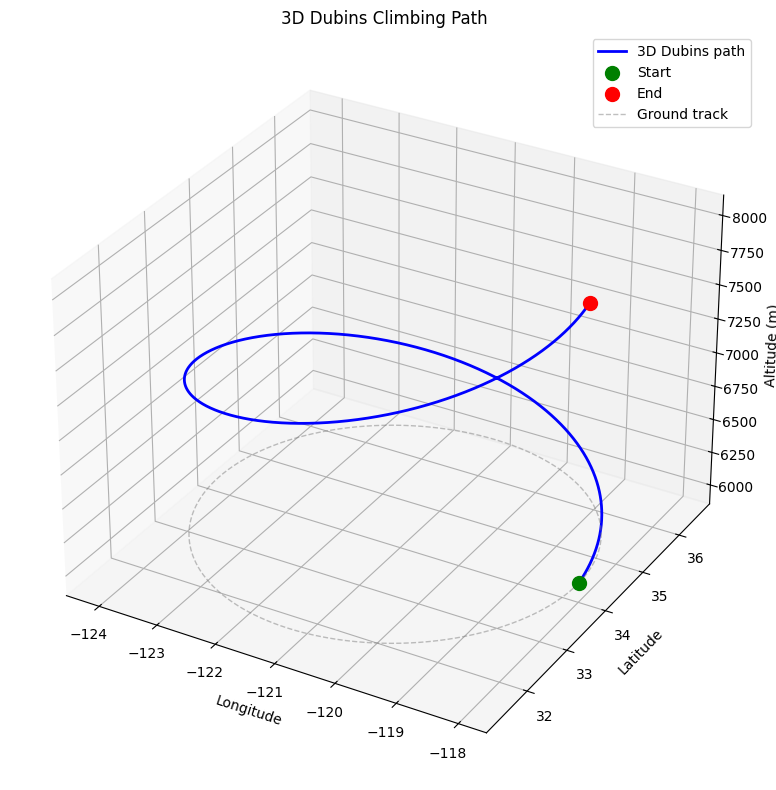

In [7]:
# 3D visualization of the climbing path
pts = path_climb.points  # (lat, lon, alt, heading, pitch)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(pts[:, 1], pts[:, 0], pts[:, 2], 'b-', linewidth=2, label='3D Dubins path')
ax.scatter(pts[0, 1], pts[0, 0], pts[0, 2], c='green', s=100, zorder=5, label='Start')
ax.scatter(pts[-1, 1], pts[-1, 0], pts[-1, 2], c='red', s=100, zorder=5, label='End')

# Project path onto ground plane
ax.plot(pts[:, 1], pts[:, 0], np.full(len(pts), pts[:, 2].min()),
        'gray', linewidth=1, alpha=0.5, linestyle='--', label='Ground track')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Altitude (m)')
ax.set_title('3D Dubins Climbing Path')
ax.legend()
plt.tight_layout()
plt.show()

### Level vs Climbing Paths

For level flight the path is purely horizontal. When altitude changes,
the path may be longer because it must respect pitch constraints.

Level path:    11.09 kilometer
Climbing path: 1793.43 kilometer
Overhead:      1782.34 kilometer


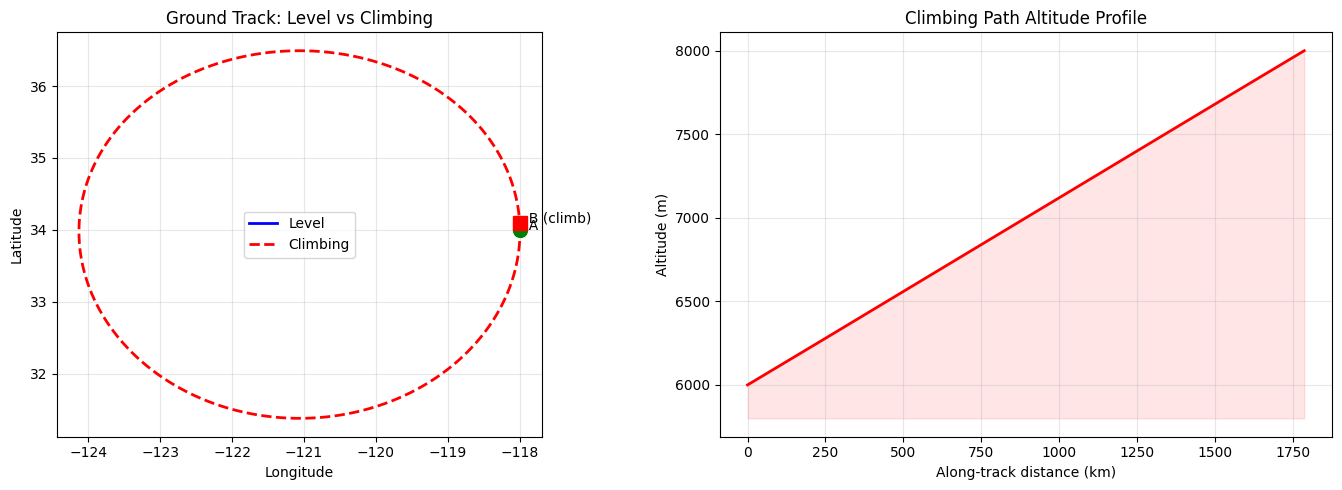

In [8]:
# Same horizontal waypoints, compare level vs climbing
wp_a = Waypoint(34.0, -118.0, 0.0, altitude_msl=6000.0, name="A")
wp_b_level = Waypoint(34.1, -118.0, 0.0, altitude_msl=6000.0, name="B (level)")
wp_b_climb = Waypoint(34.1, -118.0, 0.0, altitude_msl=8000.0, name="B (climb)")

speed_3d = ureg.Quantity(150, "knot")

path_level = DubinsPath3D(start=wp_a, end=wp_b_level, speed=speed_3d,
                          bank_angle=25.0, pitch_min=-10.0, pitch_max=10.0,
                          step_size=500.0)
path_climb = DubinsPath3D(start=wp_a, end=wp_b_climb, speed=speed_3d,
                          bank_angle=25.0, pitch_min=-10.0, pitch_max=10.0,
                          step_size=500.0)

print(f"Level path:    {path_level.length.to('km'):.2f}")
print(f"Climbing path: {path_climb.length.to('km'):.2f}")
print(f"Overhead:      {(path_climb.length - path_level.length).to('km'):.2f}")

# Side-by-side: ground track + altitude profile
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Ground track comparison
for p, label, style in [(path_level, 'Level', 'b-'), (path_climb, 'Climbing', 'r--')]:
    coords = list(p.geometry.coords)
    lons, lats = zip(*coords)
    ax1.plot(lons, lats, style, linewidth=2, label=label)

for wp, marker in [(wp_a, 'go'), (wp_b_climb, 'rs')]:
    ax1.plot(wp.longitude, wp.latitude, marker, markersize=10)
    ax1.annotate(f"  {wp.name}", (wp.longitude, wp.latitude))

ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('Ground Track: Level vs Climbing')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# Altitude profile for climbing path
pts = path_climb.points
distances = np.zeros(len(pts))
for i in range(1, len(pts)):
    dlat = pts[i, 0] - pts[i-1, 0]
    dlon = pts[i, 1] - pts[i-1, 1]
    distances[i] = distances[i-1] + np.sqrt((dlat * 111000)**2 + (dlon * 111000 * np.cos(np.radians(pts[i, 0])))**2)

ax2.plot(distances / 1000, pts[:, 2], 'r-', linewidth=2)
ax2.fill_between(distances / 1000, pts[:, 2].min() - 200, pts[:, 2], alpha=0.1, color='red')
ax2.set_xlabel('Along-track distance (km)')
ax2.set_ylabel('Altitude (m)')
ax2.set_title('Climbing Path Altitude Profile')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Effect of Pitch Limits

Tighter pitch limits force the aircraft to climb/descend more gradually,
which extends the horizontal path to accommodate the altitude change.
This demonstrates the curvature budget tradeoff.

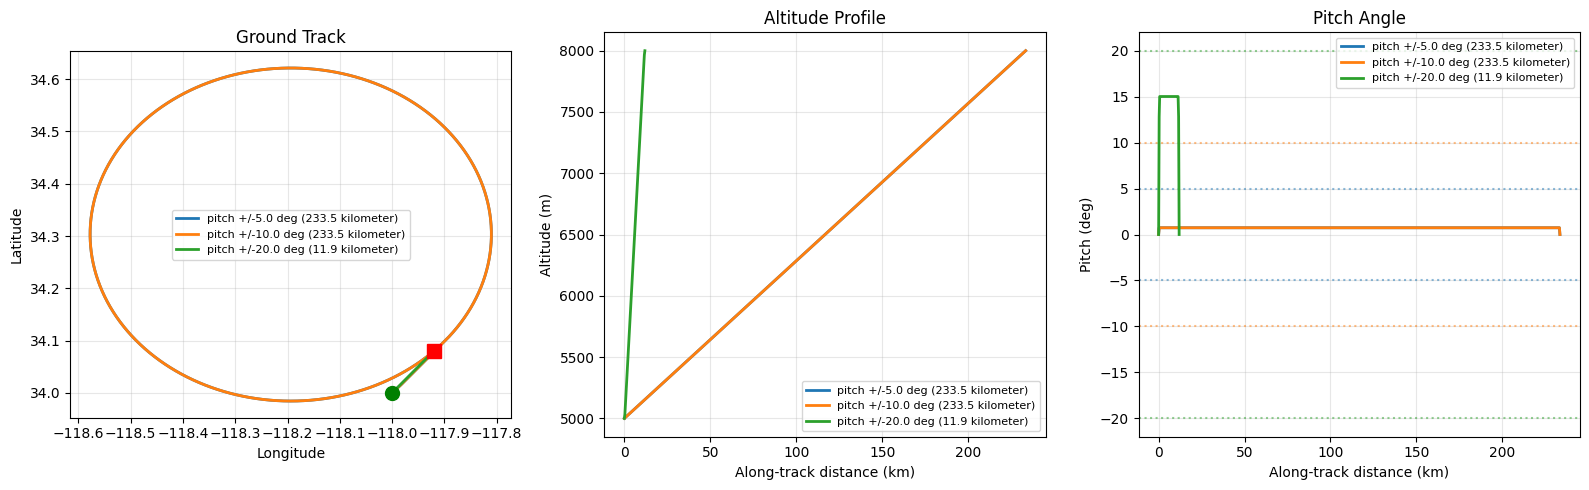

In [9]:
# Compare paths with different pitch limits
wp_start = Waypoint(34.0, -118.0, 45.0, altitude_msl=5000.0, name="Start")
wp_end = Waypoint(34.08, -117.92, 45.0, altitude_msl=8000.0, name="End")

pitch_configs = [
    (5.0, "tab:blue"),
    (10.0, "tab:orange"),
    (20.0, "tab:green"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for pitch_max, color in pitch_configs:
    p = DubinsPath3D(
        start=wp_start, end=wp_end,
        speed=ureg.Quantity(150, "knot"),
        bank_angle=25.0,
        pitch_min=-pitch_max, pitch_max=pitch_max,
        step_size=300.0,
    )
    pts = p.points
    label = f"pitch +/-{pitch_max} deg ({p.length.to('km'):.1f})"

    # Ground track
    axes[0].plot(pts[:, 1], pts[:, 0], color=color, linewidth=2, label=label)

    # Altitude profile
    along_track = np.linspace(0, p.length.to('km').magnitude, len(pts))
    axes[1].plot(along_track, pts[:, 2], color=color, linewidth=2, label=label)

    # Pitch angle along path
    axes[2].plot(along_track, pts[:, 4], color=color, linewidth=2, label=label)
    axes[2].axhline(pitch_max, color=color, linestyle=':', alpha=0.5)
    axes[2].axhline(-pitch_max, color=color, linestyle=':', alpha=0.5)

# Waypoint markers on ground track
for wp, marker in [(wp_start, 'go'), (wp_end, 'rs')]:
    axes[0].plot(wp.longitude, wp.latitude, marker, markersize=10, zorder=5)

axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Ground Track')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

axes[1].set_xlabel('Along-track distance (km)')
axes[1].set_ylabel('Altitude (m)')
axes[1].set_title('Altitude Profile')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Along-track distance (km)')
axes[2].set_ylabel('Pitch (deg)')
axes[2].set_title('Pitch Angle')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Turning with Altitude Change

The most interesting case: the aircraft must change both heading and altitude.
The curvature budget is shared between horizontal turns and vertical pitch
changes, so the 3D path may differ significantly from the 2D ground track.

Path length: 11.82 kilometer
Heading change: 0.0 -> 180.0 deg
Altitude change: 5000 -> 7000 m


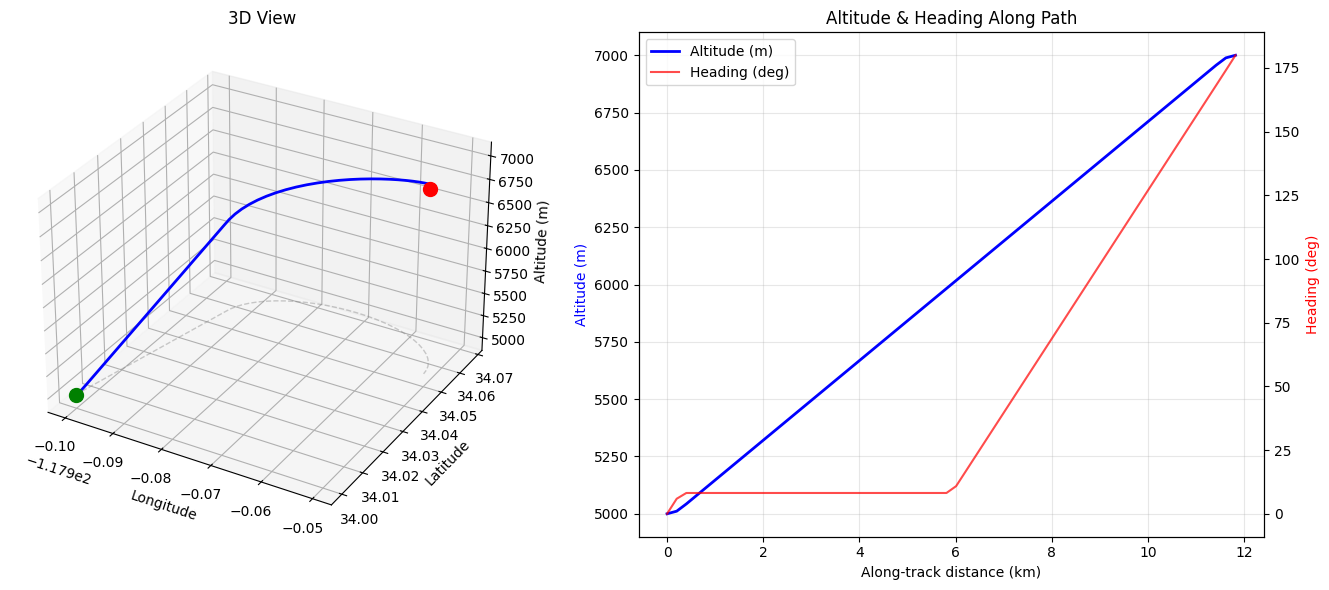

In [10]:
# 180-degree turn with 2 km altitude gain
wp_a = Waypoint(34.0, -118.0, 0.0, altitude_msl=5000.0, name="A")
wp_b = Waypoint(34.05, -117.95, 180.0, altitude_msl=7000.0, name="B")

path = DubinsPath3D(
    start=wp_a, end=wp_b,
    speed=ureg.Quantity(150, "knot"),
    bank_angle=25.0,
    pitch_min=-10.0, pitch_max=10.0,
    step_size=200.0,
)

pts = path.points
print(f"Path length: {path.length.to('km'):.2f}")
print(f"Heading change: {wp_a.heading} -> {wp_b.heading} deg")
print(f"Altitude change: 5000 -> 7000 m")

fig = plt.figure(figsize=(14, 6))

# 3D view
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(pts[:, 1], pts[:, 0], pts[:, 2], 'b-', linewidth=2)
ax1.plot(pts[:, 1], pts[:, 0], np.full(len(pts), 5000),
         'gray', linewidth=1, alpha=0.4, linestyle='--')
ax1.scatter(pts[0, 1], pts[0, 0], pts[0, 2], c='green', s=100, zorder=5)
ax1.scatter(pts[-1, 1], pts[-1, 0], pts[-1, 2], c='red', s=100, zorder=5)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_zlabel('Altitude (m)')
ax1.set_title('3D View')

# Altitude + heading profile
ax2 = fig.add_subplot(122)
along = np.linspace(0, path.length.to('km').magnitude, len(pts))
ax2.plot(along, pts[:, 2], 'b-', linewidth=2, label='Altitude (m)')
ax2_twin = ax2.twinx()
ax2_twin.plot(along, pts[:, 3] % 360, 'r-', linewidth=1.5, alpha=0.7, label='Heading (deg)')
ax2.set_xlabel('Along-track distance (km)')
ax2.set_ylabel('Altitude (m)', color='blue')
ax2_twin.set_ylabel('Heading (deg)', color='red')
ax2.set_title('Altitude & Heading Along Path')
ax2.grid(True, alpha=0.3)

# Combine legends
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.show()

## 8. Integration with Flight Lines

`FlightLine` objects expose `.waypoint1` and `.waypoint2` properties that return
`Waypoint` objects, making it easy to compute Dubins transitions between
flight lines.

### Same-Altitude Transition

A basic transition between two parallel flight lines at the same altitude.

FL1: Line 1, az=90 degree deg, length=30.0 kilometer
FL2: Line 2, az=270 degree deg, length=30.0 kilometer
Transition: 8.0 kilometer


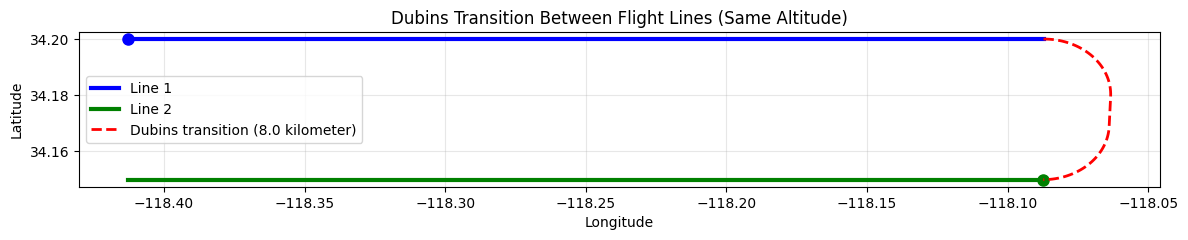

In [11]:
# Create two parallel flight lines at the same altitude
fl1 = FlightLine.center_length_azimuth(
    lat=34.20, lon=-118.25, length=ureg.Quantity(30, "km"),
    az=90.0, altitude_msl=ureg.Quantity(20000, "feet"), site_name="Line 1",
)
fl2 = FlightLine.center_length_azimuth(
    lat=34.15, lon=-118.25, length=ureg.Quantity(30, "km"),
    az=270.0, altitude_msl=ureg.Quantity(20000, "feet"), site_name="Line 2",
)

# Dubins path from end of FL1 to start of FL2
transition = DubinsPath3D(
    start=fl1.waypoint2,
    end=fl2.waypoint1,
    speed=speed,
    bank_angle=25.0,
    pitch_min=-10.0, pitch_max=10.0,
    step_size=100.0,
)

print(f"FL1: {fl1.site_name}, az={fl1.az12:.0f} deg, length={fl1.length.to('km'):.1f}")
print(f"FL2: {fl2.site_name}, az={fl2.az12:.0f} deg, length={fl2.length.to('km'):.1f}")
print(f"Transition: {transition.length.to('km'):.1f}")

fig, ax = plt.subplots(figsize=(12, 6))

# Flight lines
for fl, color in [(fl1, "blue"), (fl2, "green")]:
    coords = list(fl.geometry.coords)
    x, y = zip(*coords)
    ax.plot(x, y, color=color, linewidth=3, label=fl.site_name)
    ax.plot(x[0], y[0], "o", color=color, markersize=8)

# Transition path
lons, lats = zip(*list(transition.geometry.coords))
ax.plot(lons, lats, "r--", linewidth=2, label=f"Dubins transition ({transition.length.to('km'):.1f})")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Dubins Transition Between Flight Lines (Same Altitude)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### Multi-Altitude Transition

A 3D Dubins transition between flight lines at different altitudes — a
common scenario for stacked/multi-altitude sampling.

FL low:  Low line, alt=5000 meter
FL high: High line, alt=7000 meter
Transition: 11.77 kilometer


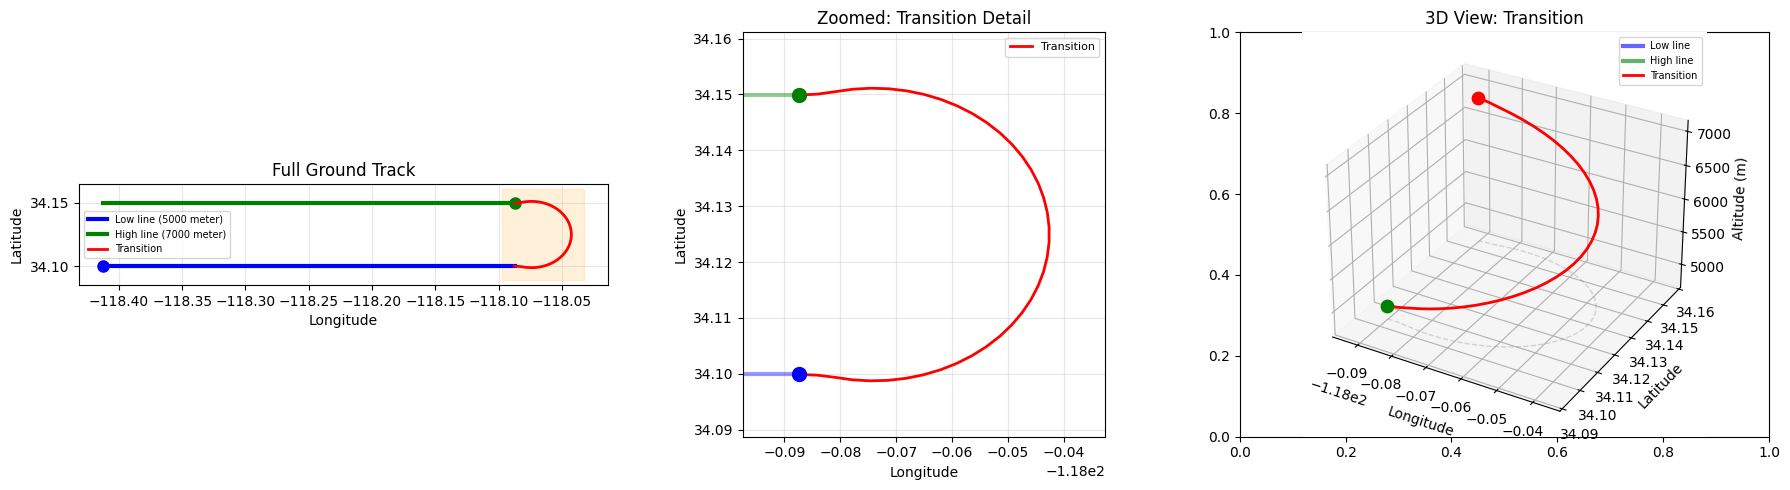

In [12]:
# Two flight lines at different altitudes
fl_low = FlightLine.center_length_azimuth(
    lat=34.10, lon=-118.25, length=ureg.Quantity(30, "km"),
    az=90.0, altitude_msl=ureg.Quantity(5000, "meter"), site_name="Low line",
)
fl_high = FlightLine.center_length_azimuth(
    lat=34.15, lon=-118.25, length=ureg.Quantity(30, "km"),
    az=270.0, altitude_msl=ureg.Quantity(7000, "meter"), site_name="High line",
)

# 3D transition from end of low line to start of high line
transition_3d = DubinsPath3D(
    start=fl_low.waypoint2,
    end=fl_high.waypoint1,
    speed=ureg.Quantity(150, "knot"),
    bank_angle=25.0,
    pitch_min=-10.0, pitch_max=10.0,
    step_size=300.0,
)

print(f"FL low:  {fl_low.site_name}, alt={fl_low.altitude_msl}")
print(f"FL high: {fl_high.site_name}, alt={fl_high.altitude_msl}")
print(f"Transition: {transition_3d.length.to('km'):.2f}")

pts_3d = transition_3d.points

# --- Full context: ground track with both flight lines ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Full ground track
ax = axes[0]
for fl, color in [(fl_low, "blue"), (fl_high, "green")]:
    coords = list(fl.geometry.coords)
    x, y = zip(*coords)
    ax.plot(x, y, color=color, linewidth=3, label=f"{fl.site_name} ({fl.altitude_msl})")
    ax.plot(x[0], y[0], 'o', color=color, markersize=8)

ax.plot(pts_3d[:, 1], pts_3d[:, 0], 'r-', linewidth=2, label='Transition')

# Show the zoom region
lon_min = pts_3d[:, 1].min() - 0.01
lon_max = pts_3d[:, 1].max() + 0.01
lat_min = pts_3d[:, 0].min() - 0.01
lat_max = pts_3d[:, 0].max() + 0.01
rect = Rectangle((lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
                  linewidth=1, edgecolor='orange', facecolor='orange', alpha=0.15)
ax.add_patch(rect)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Full Ground Track')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Panel 2: Zoomed ground track showing the transition detail
ax = axes[1]
for fl, color in [(fl_low, "blue"), (fl_high, "green")]:
    coords = list(fl.geometry.coords)
    x, y = zip(*coords)
    ax.plot(x, y, color=color, linewidth=3, alpha=0.4)
    wp_end_pt = fl.waypoint2 if fl is fl_low else fl.waypoint1
    ax.plot(wp_end_pt.longitude, wp_end_pt.latitude, 'o', color=color, markersize=10, zorder=5)

ax.plot(pts_3d[:, 1], pts_3d[:, 0], 'r-', linewidth=2, label='Transition')

ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Zoomed: Transition Detail')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Panel 3: 3D view zoomed to transition
ax = fig.add_subplot(133, projection='3d')

for fl, color in [(fl_low, "blue"), (fl_high, "green")]:
    coords = np.array(fl.geometry.coords)
    alt = fl.altitude_msl.magnitude
    mask = (coords[:, 0] > lon_min) & (coords[:, 0] < lon_max)
    if mask.any():
        ax.plot(coords[mask, 0], coords[mask, 1], [alt] * mask.sum(),
                color=color, linewidth=3, alpha=0.6, label=fl.site_name)

ax.plot(pts_3d[:, 1], pts_3d[:, 0], pts_3d[:, 2], 'r-', linewidth=2, label='Transition')
ax.plot(pts_3d[:, 1], pts_3d[:, 0], np.full(len(pts_3d), 4800),
        'gray', linewidth=1, alpha=0.3, linestyle='--')
ax.scatter(pts_3d[0, 1], pts_3d[0, 0], pts_3d[0, 2], c='green', s=80, zorder=5)
ax.scatter(pts_3d[-1, 1], pts_3d[-1, 0], pts_3d[-1, 2], c='red', s=80, zorder=5)

ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Altitude (m)')
ax.set_title('3D View: Transition')
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 9. Effect of Speed and Bank Angle

Higher speed or shallower bank angle increases the turn radius, requiring
more space for turns. This directly affects how much time is spent
maneuvering between flight lines.

In [13]:
# Compare turn radii
print("Turn radius (meters) for various speed/bank combinations:\n")
print(f"{'Speed (m/s)':<15} {'Bank 15 deg':<15} {'Bank 25 deg':<15} {'Bank 30 deg':<15} {'Bank 35 deg':<15}")
for v in [60, 80, 100, 120, 150, 200]:
    radii = []
    for ba in [15, 25, 30, 35]:
        r = v**2 / (9.8 * np.tan(np.radians(ba)))
        radii.append(f"{r:.0f}")
    print(f"{v:<15} {'  '.join(f'{r:<13}' for r in radii)}")

Turn radius (meters) for various speed/bank combinations:

Speed (m/s)     Bank 15 deg     Bank 25 deg     Bank 30 deg     Bank 35 deg    
60              1371           788            636            525          
80              2437           1400           1131           933          
100             3808           2188           1767           1457         
120             5484           3151           2545           2099         
150             8568           4924           3977           3279         
200             15233          8753           7070           5829         


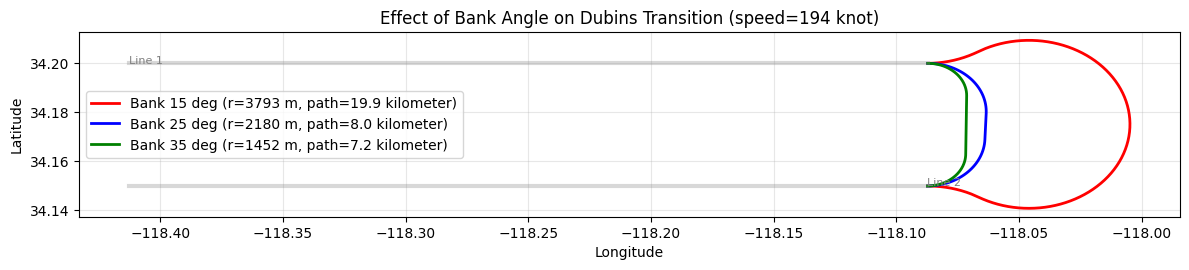

In [14]:
# Visualize the same transition at different bank angles
fig, ax = plt.subplots(figsize=(12, 7))

bank_angles = [15, 25, 35]
colors = ["red", "blue", "green"]

for ba, color in zip(bank_angles, colors):
    dp = DubinsPath3D(fl1.waypoint2, fl2.waypoint1, speed=speed,
                      bank_angle=ba, pitch_min=-10.0, pitch_max=10.0,
                      step_size=100.0)
    speed_mps = speed.to("m/s").magnitude
    r = speed_mps**2 / (9.8 * np.tan(np.radians(ba)))
    lons, lats = zip(*list(dp.geometry.coords))
    ax.plot(lons, lats, color=color, linewidth=2,
            label=f"Bank {ba} deg (r={r:.0f} m, path={dp.length.to('km'):.1f})")

# Flight lines for context
for fl, c in [(fl1, "gray"), (fl2, "gray")]:
    x, y = zip(*fl.geometry.coords)
    ax.plot(x, y, color=c, linewidth=3, alpha=0.3)
    ax.annotate(fl.site_name, (x[0], y[0]), fontsize=8, color="gray")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Effect of Bank Angle on Dubins Transition (speed={speed})")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 10. Closed-Loop Route

Dubins paths can model a complete closed-loop mission, returning the aircraft
to its starting waypoint.

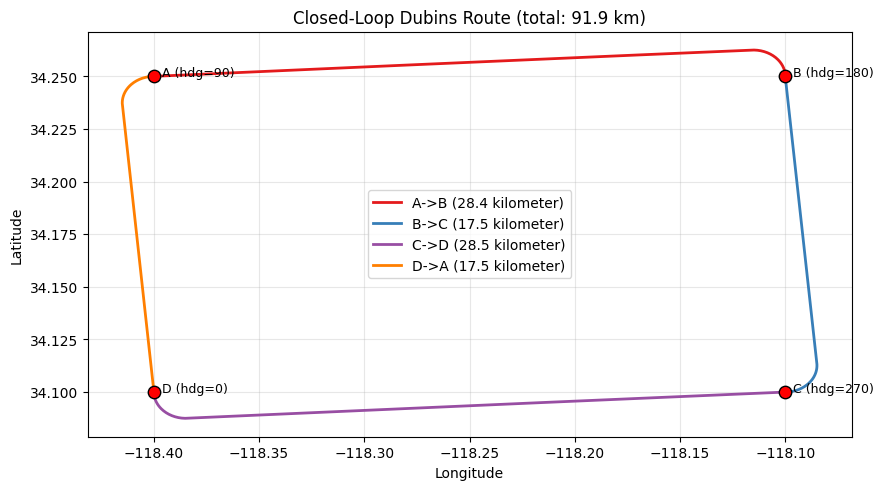

In [15]:
# Closed-loop route through 4 waypoints
loop_wps = [
    Waypoint(34.25, -118.40, 90.0, altitude_msl=ALT, name="A"),
    Waypoint(34.25, -118.10, 180.0, altitude_msl=ALT, name="B"),
    Waypoint(34.10, -118.10, 270.0, altitude_msl=ALT, name="C"),
    Waypoint(34.10, -118.40, 0.0, altitude_msl=ALT, name="D"),
    Waypoint(34.25, -118.40, 90.0, altitude_msl=ALT, name="A"),  # Return to start
]

fig, ax = plt.subplots(figsize=(9, 8))
colors = plt.cm.Set1(np.linspace(0, 0.5, len(loop_wps) - 1))

total_dist = 0
for i in range(len(loop_wps) - 1):
    dp = DubinsPath3D(loop_wps[i], loop_wps[i + 1], speed=ureg.Quantity(80, "m/s"),
                      bank_angle=25.0, pitch_min=-10.0, pitch_max=10.0,
                      step_size=50.0)
    lons, lats = zip(*list(dp.geometry.coords))
    ax.plot(lons, lats, color=colors[i], linewidth=2,
            label=f"{loop_wps[i].name}->{loop_wps[i+1].name} ({dp.length.to('km'):.1f})")
    total_dist += dp.length.to("m").magnitude

for wp in loop_wps[:-1]:
    ax.scatter(wp.longitude, wp.latitude, c="red", s=80, zorder=5, edgecolors="black")
    ax.annotate(f"  {wp.name} (hdg={wp.heading:.0f})", (wp.longitude, wp.latitude), fontsize=9)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Closed-Loop Dubins Route (total: {total_dist/1000:.1f} km)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 11. Pitch Limits from Aircraft Performance

Pitch limits can be derived from an aircraft's climb/descent rates:

$$\theta_{max} = \arctan\left(\frac{v_{climb}}{v_{horizontal}}\right)$$

For a King Air B200 at 150 knots with 500 ft/min climb rate, this gives
roughly 2 degrees. For a steeper-climbing aircraft like the ER-2 at
2000 ft/min, closer to 8 degrees.

In [16]:
# Pitch limits from climb/descent rates
aircraft_configs = {
    "King Air B200 (500 ft/min climb)": {
        "speed_kts": 150,
        "climb_fpm": 500,
        "bank_angle": 25.0,
    },
    "NASA G-III (1500 ft/min climb)": {
        "speed_kts": 200,
        "climb_fpm": 1500,
        "bank_angle": 25.0,
    },
    "NASA ER-2 (2000 ft/min climb)": {
        "speed_kts": 350,
        "climb_fpm": 2000,
        "bank_angle": 15.0,
    },
}

print(f"{'Aircraft':<40} {'Speed':<12} {'Climb rate':<15} {'Pitch limit':<12}")
print("-" * 79)
for name, cfg in aircraft_configs.items():
    v_horiz = cfg["speed_kts"] * 0.5144  # knots to m/s
    v_climb = cfg["climb_fpm"] * 0.00508  # ft/min to m/s
    pitch_deg = np.degrees(np.arctan2(v_climb, v_horiz))
    print(f"{name:<40} {cfg['speed_kts']:>4} kts    {cfg['climb_fpm']:>5} ft/min    {pitch_deg:>6.1f} deg")

Aircraft                                 Speed        Climb rate      Pitch limit 
-------------------------------------------------------------------------------
King Air B200 (500 ft/min climb)          150 kts      500 ft/min       1.9 deg
NASA G-III (1500 ft/min climb)            200 kts     1500 ft/min       4.2 deg
NASA ER-2 (2000 ft/min climb)             350 kts     2000 ft/min       3.2 deg


In [17]:
from hyplan import DynamicAviation_B200, compute_flight_plan, ureg
from hyplan.airports import Airport, initialize_data

initialize_data(countries=["US"])
b200 = DynamicAviation_B200()
kedw = Airport("KEDW")

# Show aircraft-derived pitch limits
pitch_min, pitch_max = b200.pitch_limits()
print(f"B200 pitch limits at cruise speed ({b200.cruise_speed_at(20000 * ureg.feet).to(ureg.knot)}):")
print(f"  pitch_min = {pitch_min:.2f} deg  (max descent angle)")
print(f"  pitch_max = {pitch_max:.2f} deg  (max climb angle)")

# Also show at different speeds
for spd in [ureg.Quantity(100, "knot"), ureg.Quantity(200, "knot")]:
    pmin, pmax = b200.pitch_limits(spd)
    print(f"  At {spd}: pitch_min={pmin:.2f} deg, pitch_max={pmax:.2f} deg")

B200 pitch limits at cruise speed (222.14285714285714 knot):
  pitch_min = -3.39 deg  (max descent angle)
  pitch_max = 4.52 deg  (max climb angle)
  At 100 knot: pitch_min=-8.43 deg, pitch_max=11.17 deg
  At 200 knot: pitch_min=-4.24 deg, pitch_max=5.64 deg


## 12. Integration with the Flight Plan Pipeline

The 3D Dubins solver is integrated into `compute_flight_plan()` via
`Aircraft.time_to_cruise()`. Pitch limits are derived automatically from
the aircraft's climb/descent rates.

### Flight Plan with Altitude Changes

A flight plan with multiple altitude transitions. The 3D Dubins solver
produces geometrically accurate paths that account for altitude changes
in the turn geometry.

In [18]:
# Flight sequence with altitude changes
wps = [
    Waypoint(34.7, -118.2, 0.0, altitude_msl=ureg.Quantity(10000, "feet"), name="WP1"),
    Waypoint(34.9, -118.0, 45.0, altitude_msl=ureg.Quantity(20000, "feet"), name="WP2"),
    Waypoint(35.1, -118.2, 180.0, altitude_msl=ureg.Quantity(15000, "feet"), name="WP3"),
    Waypoint(34.9, -118.4, 270.0, altitude_msl=ureg.Quantity(20000, "feet"), name="WP4"),
]

plan = compute_flight_plan(b200, wps, takeoff_airport=kedw, return_airport=kedw)

total_time = plan["time_to_segment"].sum()
total_dist = plan["distance"].dropna().sum()
print(f"Flight plan: {total_dist:.1f} nm, {total_time:.1f} min ({total_time/60:.1f} hr)")
print(f"Segments: {len(plan)}")
for seg_type in plan["segment_type"].unique():
    mask = plan["segment_type"] == seg_type
    t = plan.loc[mask, "time_to_segment"].sum()
    d = plan.loc[mask, "distance"].dropna().sum()
    print(f"  {seg_type:<15s}: {d:>8.1f} nm, {t:>6.1f} min")

Flight plan: 172.8 nm, 49.2 min (0.8 hr)
Segments: 5
  takeoff        :     21.6 nm,    6.4 min
  climb          :     95.5 nm,   25.8 min
  descent        :     55.6 nm,   17.0 min


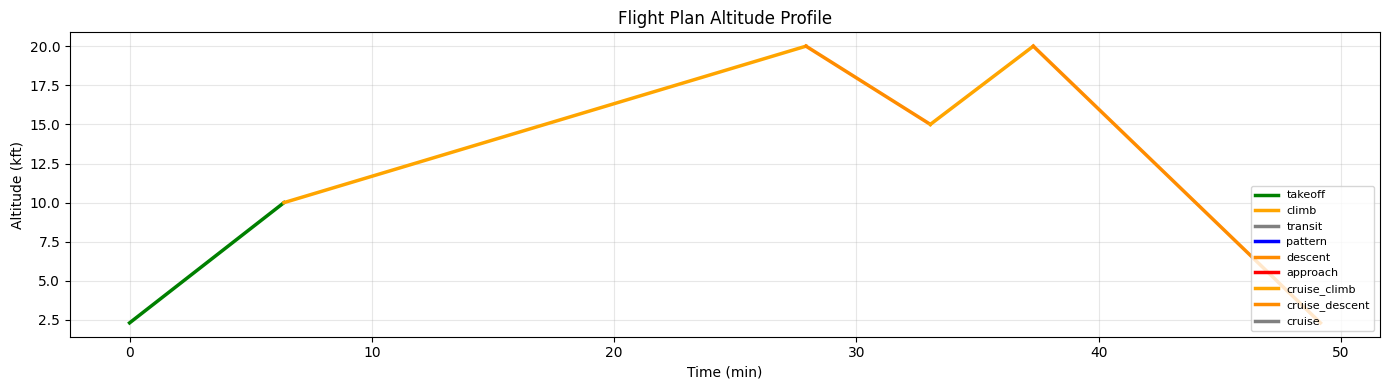

In [19]:
SEG_COLORS = {
    "takeoff": "green", "climb": "orange", "transit": "gray",
    "pattern": "blue", "descent": "darkorange", "approach": "red",
    "cruise_climb": "orange", "cruise_descent": "darkorange",
    "cruise": "gray",
}

fig, ax = plt.subplots(figsize=(14, 4))

cum_time = 0
for _, row in plan.iterrows():
    t = row["time_to_segment"] if row["time_to_segment"] is not None else 0
    color = SEG_COLORS.get(row["segment_type"], "black")
    ax.plot([cum_time, cum_time + t],
            [row["start_altitude"] / 1000, row["end_altitude"] / 1000],
            color=color, linewidth=2.5)
    cum_time += t

ax.set_xlabel("Time (min)")
ax.set_ylabel("Altitude (kft)")
ax.set_title("Flight Plan Altitude Profile")
ax.grid(True, alpha=0.3)

handles = [Line2D([0], [0], color=c, linewidth=2.5) for c in SEG_COLORS.values()]
ax.legend(handles, list(SEG_COLORS.keys()), loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

### Stacked Racetrack with 3D Dubins

A complete flight plan from KEDW using 3D Dubins for all transitions,
including a stacked racetrack pattern with multiple altitude transitions.

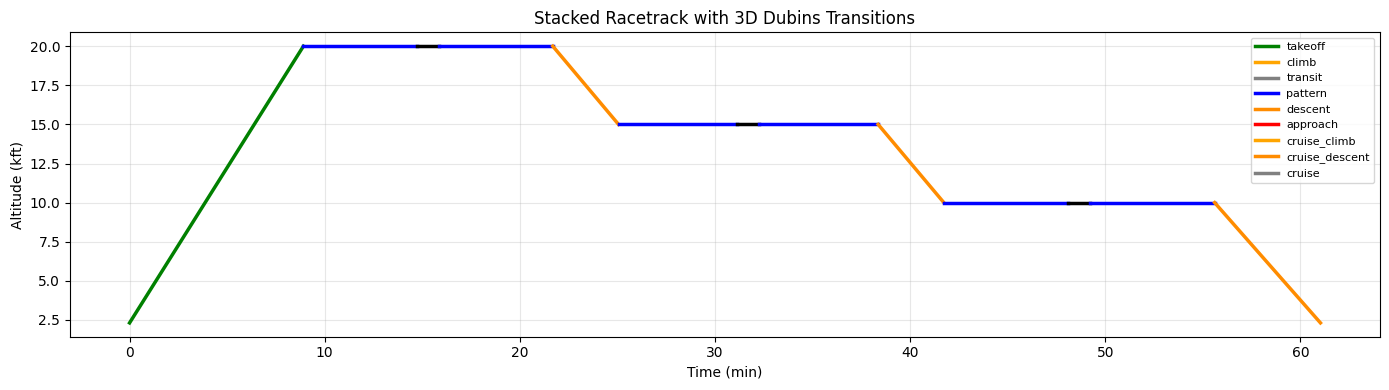

Stacked racetrack: 215.1 nm, 61.0 min (1.0 hr)
Segments: 13


In [20]:
from hyplan.flight_patterns import racetrack

# Stacked racetrack — the ideal test case for 3D Dubins
# since it involves many altitude transitions
CENTER = (34.9, -117.9)
ALT_STACK = ureg.Quantity(20000, "feet")

stack_alts = [ureg.Quantity(a, "feet") for a in [20000, 15000, 10000]]
wps_stacked = racetrack(
    CENTER, 0.0, ALT_STACK, ureg.Quantity(40, "km"),
    n_legs=2, offset=ureg.Quantity(5, "km"),
    stack_altitudes=stack_alts,
)

plan_stacked = compute_flight_plan(
    b200, wps_stacked,
    takeoff_airport=kedw, return_airport=kedw,
)

# Altitude profile
fig, ax = plt.subplots(figsize=(14, 4))
cum_time = 0
for _, row in plan_stacked.iterrows():
    t = row["time_to_segment"] if row["time_to_segment"] is not None else 0
    color = SEG_COLORS.get(row["segment_type"], "black")
    ax.plot([cum_time, cum_time + t],
            [row["start_altitude"] / 1000, row["end_altitude"] / 1000],
            color=color, linewidth=2.5)
    cum_time += t
ax.set_xlabel("Time (min)")
ax.set_ylabel("Altitude (kft)")
ax.set_title("Stacked Racetrack with 3D Dubins Transitions")
ax.grid(True, alpha=0.3)

handles = [Line2D([0], [0], color=c, linewidth=2.5) for c in SEG_COLORS.values()]
ax.legend(handles, list(SEG_COLORS.keys()), loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# Summary
total_time = plan_stacked["time_to_segment"].sum()
total_dist = plan_stacked["distance"].dropna().sum()
print(f"Stacked racetrack: {total_dist:.1f} nm, {total_time:.1f} min ({total_time/60:.1f} hr)")
print(f"Segments: {len(plan_stacked)}")

## Summary

| Class | Purpose |
|-------|--------|
| `Waypoint(lat, lon, heading, altitude_msl, name)` | Oriented position for path planning |
| `DubinsPath3D(start, end, speed, bank_angle, pitch_min, pitch_max, ...)` | Shortest curved path between two waypoints with pitch constraints |

| Property/Method | Description |
|-----------------|-------------|
| `Waypoint.geometry` | Shapely Point |
| `Waypoint.to_dict()` | Dictionary serialization |
| `DubinsPath3D.geometry` | LineString ground track (lon, lat) |
| `DubinsPath3D.geometry_3d` | LineString with altitude (lon, lat, alt) |
| `DubinsPath3D.length` | Total path length (Pint Quantity) |
| `DubinsPath3D.min_turn_radius` | Minimum 3D turn radius |
| `DubinsPath3D.points` | Array of (lat, lon, alt, heading, pitch) |
| `DubinsPath3D.to_dict()` | Dictionary with coordinates, headings, distance |
| `FlightLine.waypoint1` / `.waypoint2` | Extract waypoints from flight line endpoints |

**Key relationships:**
- Turn radius = $v^2 / (g \cdot \tan(\theta))$ — determined by speed and bank angle
- Higher speed or shallower bank = larger turns = longer transitions
- The minimum turn radius is shared between horizontal and vertical curvature: $1/\rho_{min}^2 = 1/\rho_h^2 + 1/\rho_v^2$
- Tighter pitch limits force longer horizontal paths to accommodate altitude change
- For level flight, the vertical component vanishes and the path reduces to a horizontal Dubins path
- `FlightLine` waypoints integrate directly with `DubinsPath3D` for route planning
- Pitch limits are derived automatically from aircraft climb/descent performance via `Aircraft.pitch_limits()`